In [24]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_86.jpg
/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_185.jpg
/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_141.jpg
/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_207.jpg
/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_211.jpg
/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_112.jpg
/kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters/Bali/Bali/letter/na/Na_91.jpg
/kaggle/input/datasets/dianle

KeyboardInterrupt: 

In [43]:
import os, sys, subprocess
from pathlib import Path

IN_KAGGLE = Path('/kaggle/input').exists()

REQUIRED = ['optuna', 'catboost', 'lightgbm', 'xgboost']
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

print(f'Environment : {"Kaggle" if IN_KAGGLE else "Colab" if IN_COLAB else "Local"}')
print('Packages OK.')

Environment : Kaggle
Packages OK.


In [44]:
import time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA avail  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')

PyTorch     : 2.10.0+cu128
CUDA avail  : True
GPU         : Tesla T4


In [45]:
import os
import time
import torch
import pandas as pd
import seaborn as sns
from pathlib import Path

# ==========================================
# 1. Environment & Constants
# ==========================================
IN_KAGGLE = os.path.exists('/kaggle/input')
# Deteksi Colab yang lebih aman
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cpu')
)
USE_GPU_TREES = DEVICE.type == 'cuda'

# Hyperparameters
IMG_SIZE         = 224
BATCH_SIZE       = 128 if DEVICE.type == 'cuda' else 64
NUM_WORKERS      = os.cpu_count() if DEVICE.type == 'cuda' else 0
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
PCA_COMPONENTS   = 256
OPTUNA_TRIALS    = 10
TUNE_SUBSAMPLE   = 0.25
FINAL_ESTIMATORS = 400

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp'}
PALETTE       = sns.color_palette('tab10', n_colors=9)

# ==========================================
# 2. Robust Path Resolver
# ==========================================
def resolve_dataset_root() -> Path:
    if IN_KAGGLE:
        for p in Path('/kaggle/input').rglob('Bali'):
            if p.is_dir():
                return p.parent
    
    candidates = [Path('/content/datasetscript'), Path('./datasetscript'), Path('../datasetscript')]
    for c in candidates:
        if c.exists() and (c / 'Bali').exists():
            return c
            
    raise FileNotFoundError("Dataset root tidak ditemukan!")

# 2. Baru panggil fungsinya
DATASET_ROOT = resolve_dataset_root()

DATASET_ROOT = resolve_dataset_root()
WORK_DIR     = Path('/kaggle/working') if IN_KAGGLE else Path('.')
OUTPUT_DIR   = WORK_DIR / 'models'
FEATURES_DIR = WORK_DIR / 'features'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# 3. Dynamic Script Configs
# ==========================================
def get_valid_path(script_name, sub_paths):
    valid_resolved = []
    
    # Jika sub_paths kosong, kita tetap ingin mengecek folder utamanya
    search_targets = sub_paths if sub_paths else [""]
    
    for sub in search_targets:
        # Urutan prioritas pengecekan folder
        options = [
            DATASET_ROOT / script_name / script_name / sub, # Nested (Bali/Bali/letter)
            DATASET_ROOT / script_name / sub,                # Normal (Sunda/consonant)
            DATASET_ROOT / script_name / script_name         # Direct Double (Batak/Batak)
        ]
        
        found = False
        for p in options:
            if p.exists() and p.is_dir():
                # Masukkan path relatif terhadap DATASET_ROOT
                valid_resolved.append(str(p.relative_to(DATASET_ROOT)))
                found = True
                break
        
        # Fallback terakhir: folder script itu sendiri
        if not found:
            valid_resolved.append(script_name)
                
    return list(set(valid_resolved))

SCRIPT_CONFIGS = {
    'Bali':    {'paths': get_valid_path('Bali', ['letter'])},
    'Batak':   {'paths': get_valid_path('Batak', [])},
    'Jawa':    {'paths': get_valid_path('Jawa', ['all_class'])},
    'Jawi':    {'paths': get_valid_path('Jawi', ['letter'])},
    'Kawi':    {'paths': get_valid_path('Kawi', [])},
    'Lampung': {'paths': get_valid_path('Lampung', [])},
    'Lontara': {'paths': get_valid_path('Lontara', [])},
    'Pallawa': {'paths': get_valid_path('Pallawa', [])},
    'Sunda':   {'paths': get_valid_path('Sunda', ['consonant', 'vowel'])},
}

print(f'Dataset root : {DATASET_ROOT}')
print(f'Working dir  : {WORK_DIR}')
print(f'Device       : {DEVICE}  (GPU tree training: {USE_GPU_TREES})')
print(f'Batch size   : {BATCH_SIZE}  |  workers: {NUM_WORKERS}')

# ==========================================
# 4. Dataset Loader
# ==========================================
def load_dataset(root: Path, configs: dict) -> pd.DataFrame:
    records = []
    for script, cfg in configs.items():
        for rel in cfg['paths']:
            script_dir = root / rel
            if not script_dir.exists():
                continue
            
            # Iterasi folder kelas
            for cls_dir in sorted(script_dir.iterdir()):
                if not cls_dir.is_dir():
                    continue
                
                label = f'{script}_{cls_dir.name}'
                for img in cls_dir.iterdir():
                    if img.suffix.lower() in VALID_EXTS:
                        records.append({
                            'filepath': str(img),
                            'label'   : label,
                            'script'  : script,
                            'class'   : cls_dir.name,
                        })
    return pd.DataFrame(records)

# ==========================================
# 5. Execution
# ==========================================
t0 = time.time()
df = load_dataset(DATASET_ROOT, SCRIPT_CONFIGS)

print("-" * 40)
if not df.empty:
    print(f'Loaded {len(df):,} images in {time.time()-t0:.1f}s')
    print(f'Scripts : {df["script"].nunique()}   |   Classes : {df["label"].nunique()}')
else:
    print("Dataset kosong! Cek kembali struktur folder.")

Dataset root : /kaggle/input/datasets/dianlestari187/indonesian-local-script-characters/Indonesian Local Script Characters
Working dir  : /kaggle/working
Device       : cuda  (GPU tree training: True)
Batch size   : 128  |  workers: 4
----------------------------------------
Loaded 55,713 images in 0.4s
Scripts : 9   |   Classes : 228


In [46]:
# Composition table (mirrors paper Table I)
summary = (
    df.groupby('script')
      .agg(Classes=('label', 'nunique'), Images=('filepath', 'count'))
      .reset_index()
)

summary['Percentage'] = (summary['Images'] / summary['Images'].sum() * 100).round(2)
summary = summary.sort_values('Images', ascending=False).reset_index(drop=True)

# Tambahkan baris Total
total = pd.DataFrame([['Total', summary['Classes'].sum(), summary['Images'].sum(), 100.0]],
                      columns=summary.columns)

print(pd.concat([summary, total], ignore_index=True).to_string(index=False))

# Imbalance Ratio
cls_counts = df.groupby('label')['filepath'].count()
if not cls_counts.empty:
    print(f'\nImbalance ratio (max/min class): {cls_counts.max() / cls_counts.min():.1f}x')

display(df.head())

 script  Classes  Images  Percentage
  Sunda       32   20224     36.3000
   Jawa       20    9995     17.9400
   Kawi       31    6246     11.2100
Lampung       20    4996      8.9700
   Bali       18    4493      8.0600
Pallawa       33    3960      7.1100
Lontara       23    2299      4.1300
  Batak       19    1900      3.4100
   Jawi       32    1600      2.8700
  Total      228   55713    100.0000

Imbalance ratio (max/min class): 14.5x


,filepath,label,script,class
0,/kaggle/input/datasets/dianlestari187/indonesi...,Bali_ba,Bali,ba
1,/kaggle/input/datasets/dianlestari187/indonesi...,Bali_ba,Bali,ba
2,/kaggle/input/datasets/dianlestari187/indonesi...,Bali_ba,Bali,ba
3,/kaggle/input/datasets/dianlestari187/indonesi...,Bali_ba,Bali,ba
4,/kaggle/input/datasets/dianlestari187/indonesi...,Bali_ba,Bali,ba


In [47]:
# Composition table (mirrors paper Table I)
summary = (
    df.groupby('script')
      .agg(Classes=('label', 'nunique'), Images=('filepath', 'count'))
      .reset_index()
)
summary['Percentage'] = (summary['Images'] / summary['Images'].sum() * 100).round(2)
summary = summary.sort_values('Images', ascending=False).reset_index(drop=True)
total = pd.DataFrame([['Total', summary['Classes'].sum(), summary['Images'].sum(), 100.0]],
                      columns=summary.columns)
print(pd.concat([summary, total], ignore_index=True).to_string(index=False))

cls_counts = df.groupby('label')['filepath'].count()
print(f'\nImbalance ratio (max/min class): {cls_counts.max() / cls_counts.min():.1f}x')

 script  Classes  Images  Percentage
  Sunda       32   20224     36.3000
   Jawa       20    9995     17.9400
   Kawi       31    6246     11.2100
Lampung       20    4996      8.9700
   Bali       18    4493      8.0600
Pallawa       33    3960      7.1100
Lontara       23    2299      4.1300
  Batak       19    1900      3.4100
   Jawi       32    1600      2.8700
  Total      228   55713    100.0000

Imbalance ratio (max/min class): 14.5x


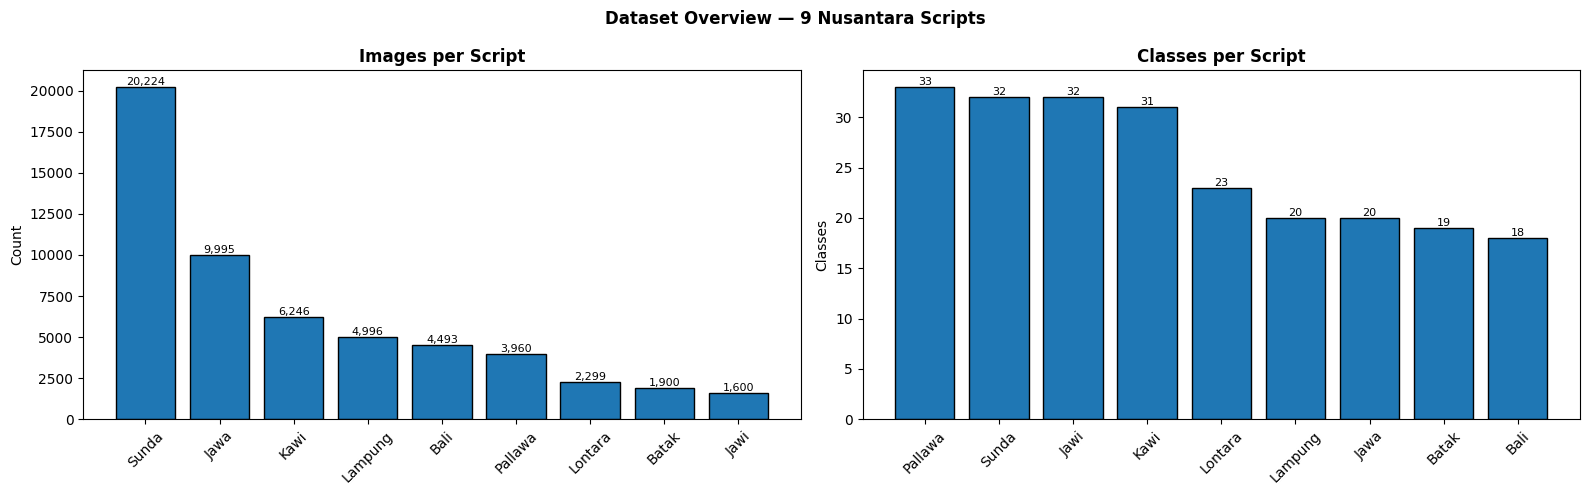

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
img_per_script = df.groupby('script')['filepath'].count().sort_values(ascending=False)
cls_per_script = df.groupby('script')['label'].nunique().sort_values(ascending=False)

for ax, series, title, ylab in [
    (axes[0], img_per_script, 'Images per Script',  'Count'),
    (axes[1], cls_per_script, 'Classes per Script', 'Classes'),
]:
    bars = ax.bar(series.index, series.values, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylab)
    ax.tick_params(axis='x', rotation=45)
    for b in bars:
        ax.annotate(f'{int(b.get_height()):,}',
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Dataset Overview — 9 Nusantara Scripts', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_script_overview.png', dpi=130, bbox_inches='tight')
plt.show()

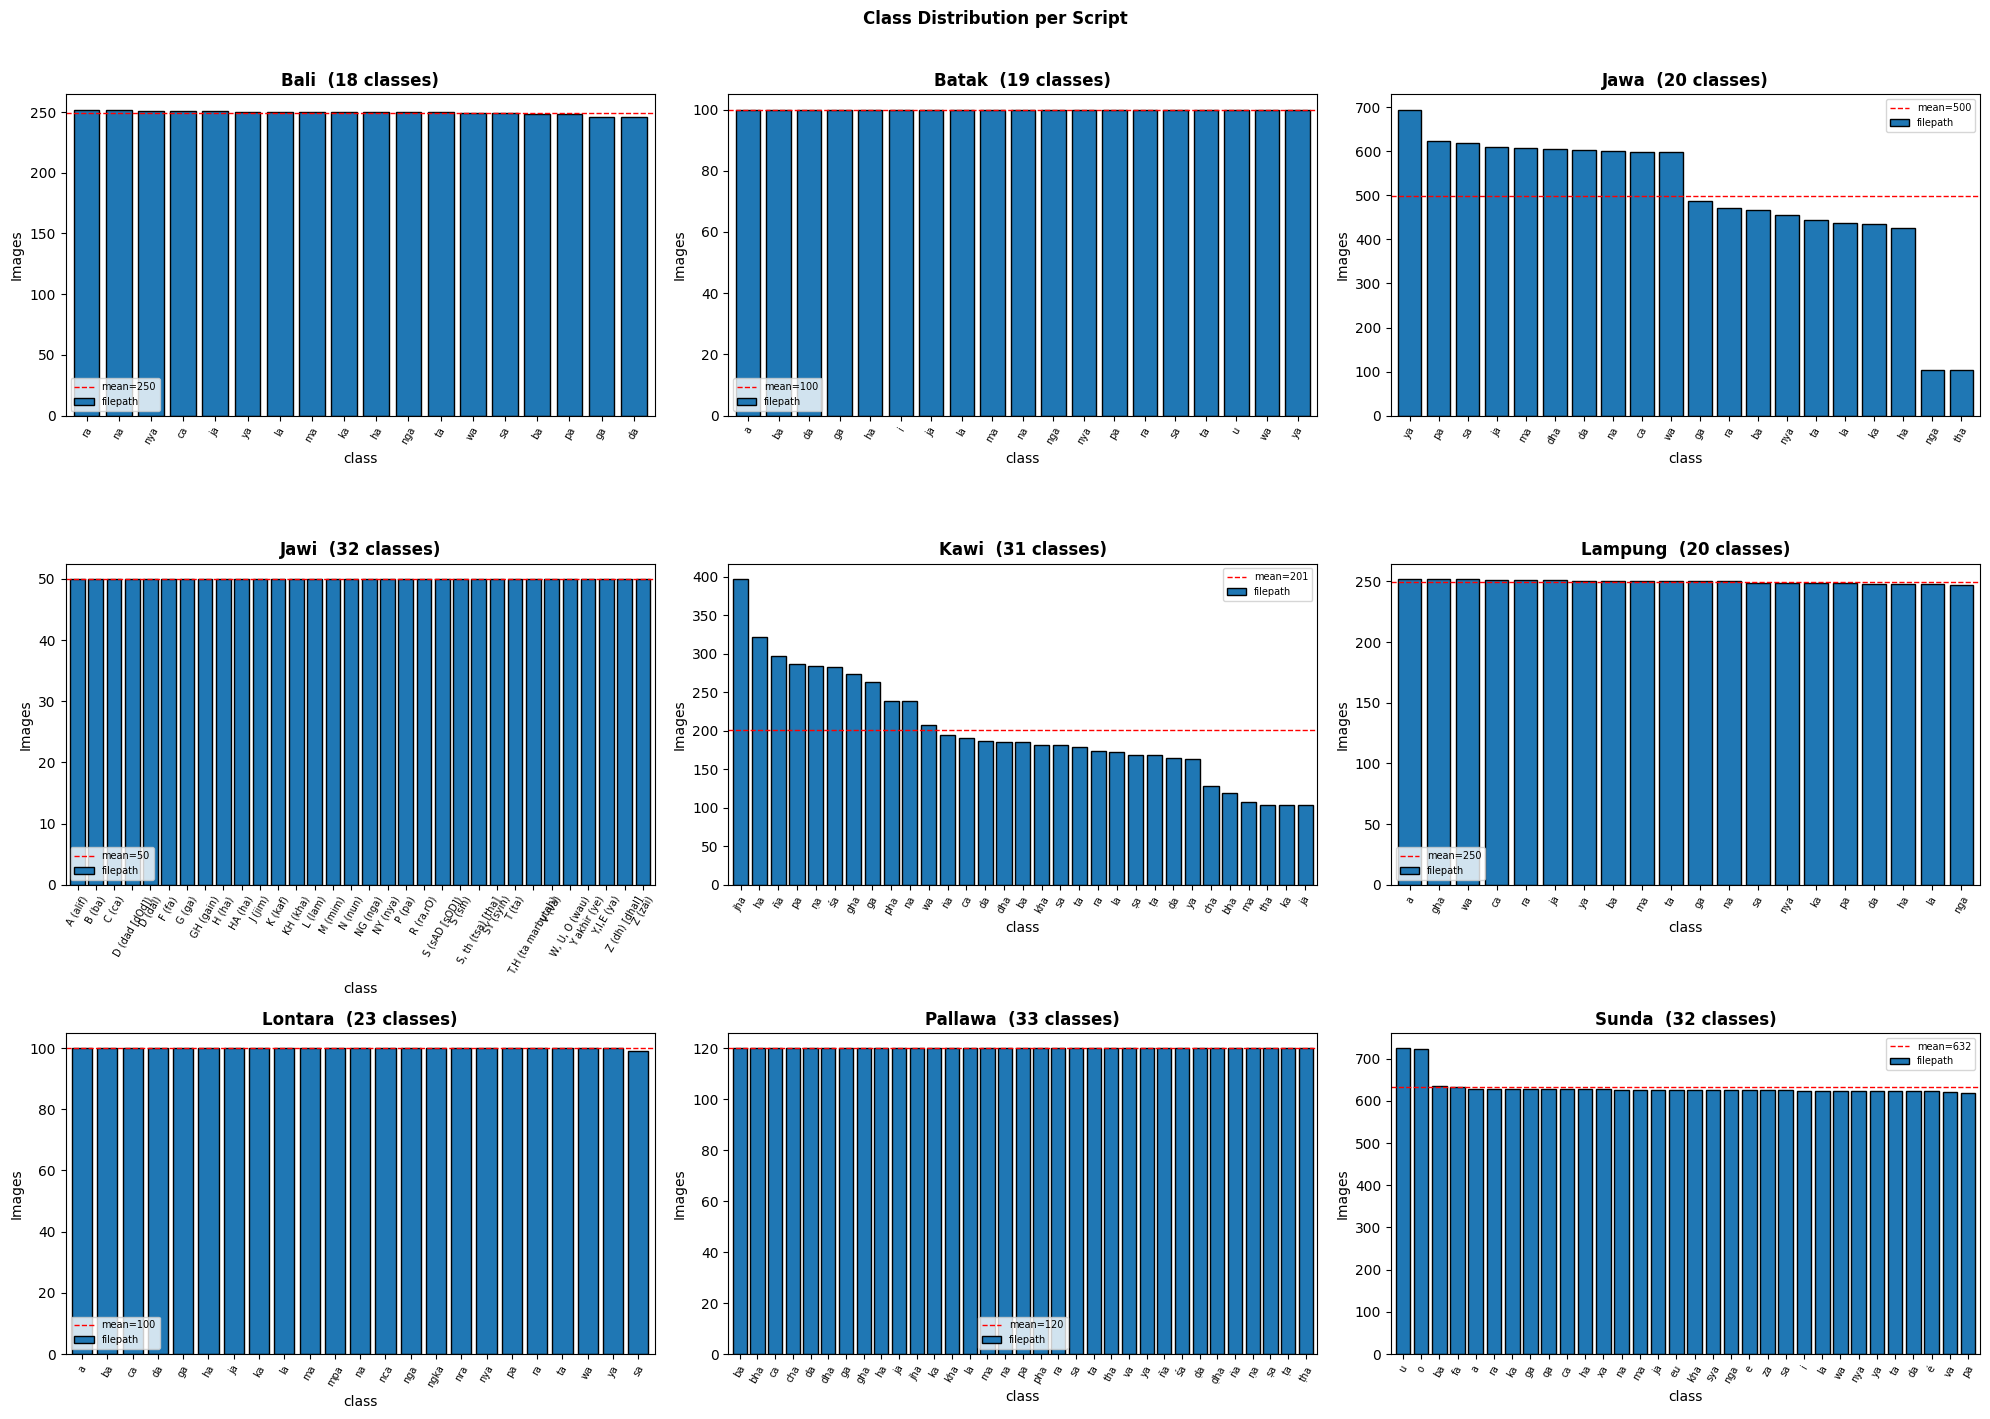

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
for idx, (ax, script) in enumerate(zip(axes.flatten(), sorted(df['script'].unique()))):
    sub = df[df['script'] == script].groupby('class')['filepath'].count().sort_values(ascending=False)
    sub.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
    ax.set_title(f'{script}  ({len(sub)} classes)', fontweight='bold')
    ax.set_ylabel('Images')
    ax.tick_params(axis='x', rotation=60, labelsize=7)
    ax.axhline(sub.mean(), color='red', linestyle='--', linewidth=1, label=f'mean={sub.mean():.0f}')
    ax.legend(fontsize=7)

plt.suptitle('Class Distribution per Script', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

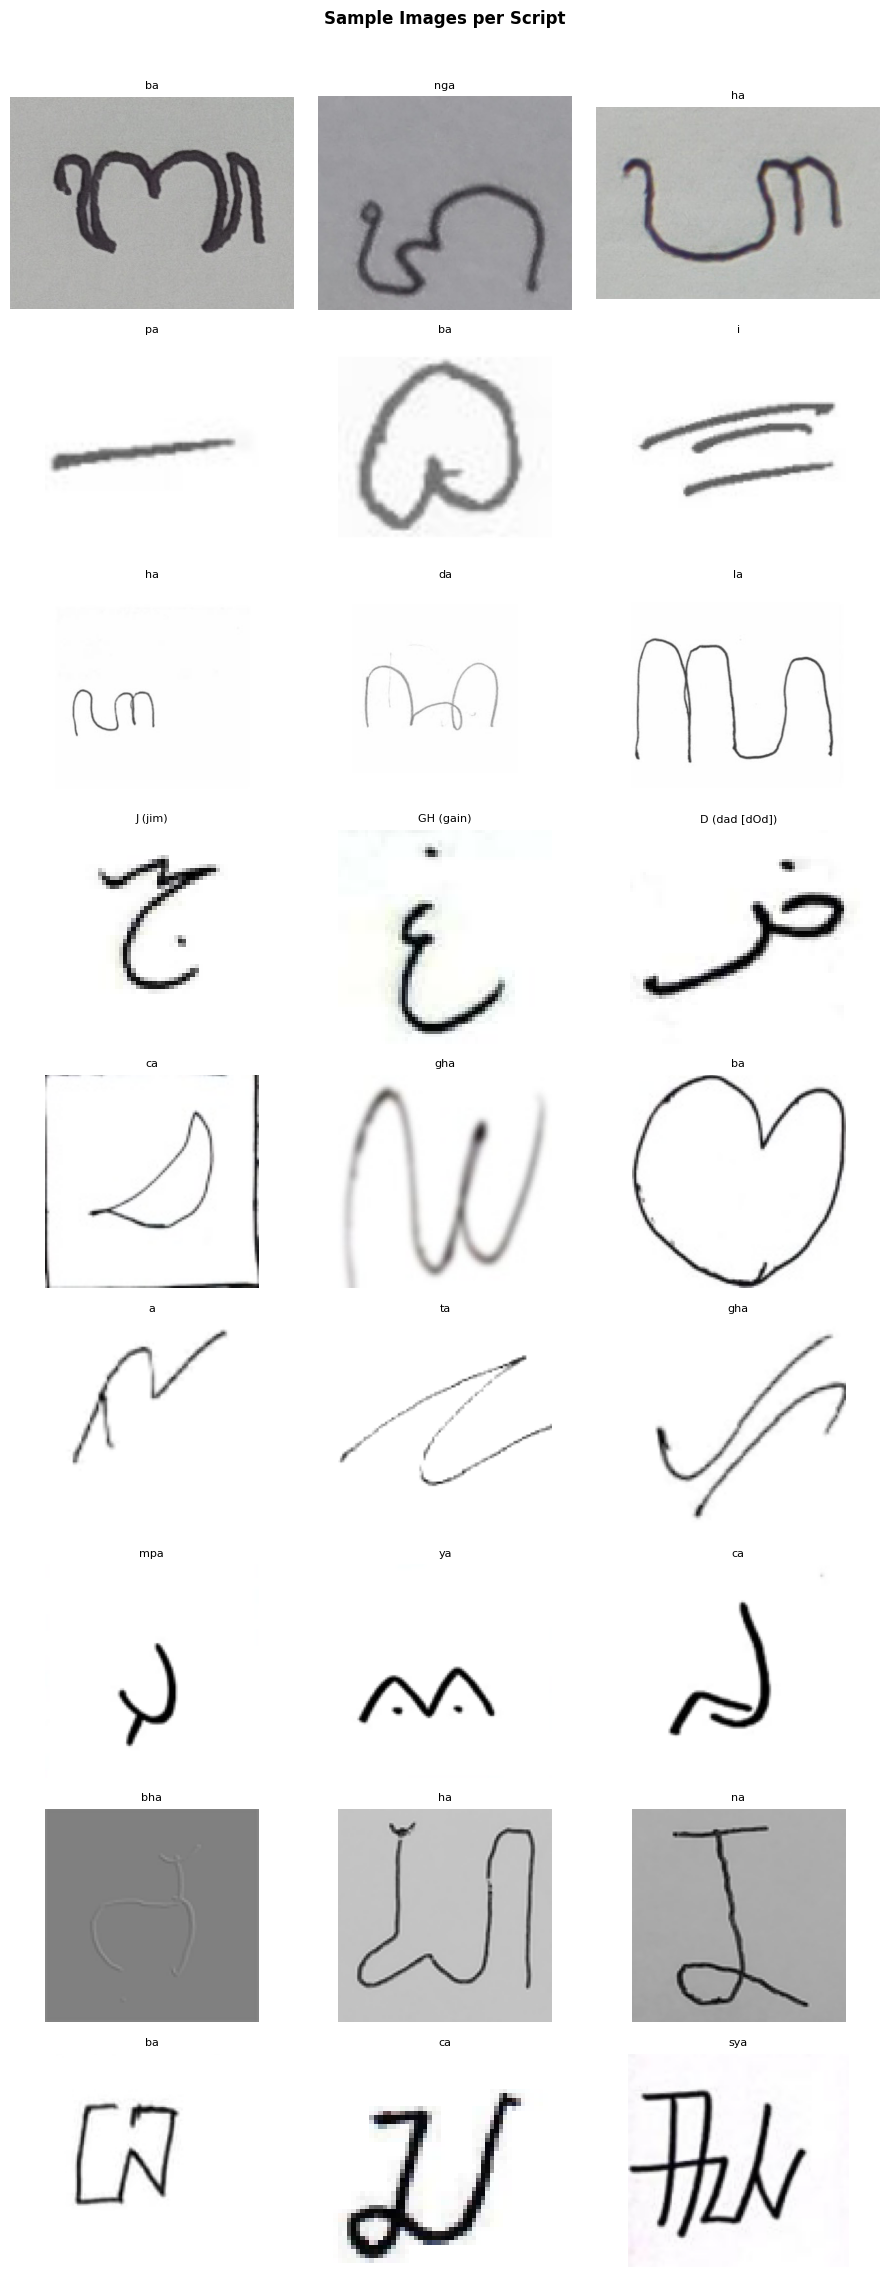

In [50]:
np.random.seed(RANDOM_STATE)
scripts = sorted(df['script'].unique())
N_SAMPLES = 3

fig, axes = plt.subplots(len(scripts), N_SAMPLES, figsize=(N_SAMPLES * 3, len(scripts) * 2.5))
for row, script in enumerate(scripts):
    samples = df[df['script'] == script].sample(n=N_SAMPLES, random_state=RANDOM_STATE)
    for col, (_, rec) in enumerate(samples.iterrows()):
        img = Image.open(rec['filepath']).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(rec['class'], fontsize=8)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(script, fontsize=10, fontweight='bold', rotation=90, labelpad=10)

plt.suptitle('Sample Images per Script', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_sample_images.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 2. Preprocessing & Stratified Split

In [52]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

np.save(OUTPUT_DIR / 'class_names.npy', CLASS_NAMES)
joblib.dump(le, OUTPUT_DIR / 'label_encoder.pkl')

X_all = df['filepath'].values
y_all = df['label_enc'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all,
)
np.save(FEATURES_DIR / 'labels_train.npy', y_train)
np.save(FEATURES_DIR / 'labels_test.npy',  y_test)

print(f'Classes : {N_CLASSES}')
print(f'Train   : {len(X_train):,}   Test : {len(X_test):,}')

Classes : 228
Train   : 44,570   Test : 11,143


In [53]:
# Preprocessing: grayscale -> mean-blur binarize -> replicate to 3-ch RGB -> normalize
def binarize_pil(gray: Image.Image) -> Image.Image:
    blurred = np.array(gray.filter(ImageFilter.GaussianBlur(radius=1)))
    thresh  = blurred.mean()
    binary  = np.where(np.array(gray) < thresh, 0, 255).astype(np.uint8)
    return Image.fromarray(binary, mode='L')

def to_rgb_3ch(gray: Image.Image) -> Image.Image:
    return Image.merge('RGB', [gray, gray, gray])

BASE_TRANSFORM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class NusantaraDataset(Dataset):
    def __init__(self, filepaths, labels):
        self.filepaths = filepaths
        self.labels    = labels

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx])
        if img.mode == 'RGBA':
            bg = Image.new('RGB', img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            img = bg
        elif img.mode == 'P':
            img = img.convert('RGBA').convert('RGB')
        else:
            img = img.convert('RGB')
        gray   = img.convert('L')
        binary = binarize_pil(gray)
        rgb    = to_rgb_3ch(binary)
        return BASE_TRANSFORM(rgb), int(self.labels[idx])

tensor, lbl = NusantaraDataset(X_train[:1], y_train[:1])[0]
print(f'Tensor shape : {tuple(tensor.shape)}   label : {lbl} -> {CLASS_NAMES[lbl]}')

Tensor shape : (3, 224, 224)   label : 136 -> Lampung_sa


---
## 3. Feature Extraction — Frozen CNN Backbones

Two ImageNet-pretrained backbones produce 1280-d feature vectors. Mixed precision (fp16) is used on CUDA for ~2× speedup with no accuracy loss.

In [54]:
def build_extractor(name: str) -> nn.Module:
    if name == 'mobilenet_v2':
        m = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier = nn.Identity()
    elif name == 'efficientnet_b0':
        m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier = nn.Identity()
    else:
        raise ValueError(name)
    for p in m.parameters():
        p.requires_grad = False
    return m.eval().to(DEVICE)

@torch.no_grad()
def extract_features(extractor, filepaths, labels, desc=''):
    ds = NusantaraDataset(filepaths, labels)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
    )
    use_amp = (DEVICE.type == 'cuda')
    feats, lbls = [], []
    for imgs, batch_lbls in tqdm(loader, desc=desc, unit='batch'):
        imgs = imgs.to(DEVICE, non_blocking=use_amp)
        if use_amp:
            with torch.amp.autocast('cuda', dtype=torch.float16):
                f = extractor(imgs)
            f = f.float()
        else:
            f = extractor(imgs)
        feats.append(f.cpu().numpy())
        lbls.extend(batch_lbls.numpy().tolist())
    return np.vstack(feats), np.array(lbls)

print('Feature extraction utilities ready.')

Feature extraction utilities ready.


In [55]:
BACKBONES = ['mobilenet_v2', 'efficientnet_b0']
FEATURES  = {}

for bb in BACKBONES:
    tr_path = FEATURES_DIR / f'features_train_{bb}.npy'
    te_path = FEATURES_DIR / f'features_test_{bb}.npy'

    if tr_path.exists() and te_path.exists():
        print(f'[{bb}] loading cached features...')
        X_tr = np.load(tr_path)
        X_te = np.load(te_path)
        y_tr = np.load(FEATURES_DIR / 'labels_train.npy')
        y_te = np.load(FEATURES_DIR / 'labels_test.npy')
    else:
        print(f'\n[{bb}] extracting features...')
        extractor = build_extractor(bb)
        t0 = time.time()
        X_tr, y_tr = extract_features(extractor, X_train, y_train, f'{bb} | train')
        X_te, y_te = extract_features(extractor, X_test,  y_test,  f'{bb} | test')
        print(f'  elapsed: {time.time()-t0:.0f}s')
        np.save(tr_path, X_tr)
        np.save(te_path, X_te)
        del extractor
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
        elif DEVICE.type == 'mps':
            torch.mps.empty_cache()

    FEATURES[bb] = {'train': (X_tr, y_tr), 'test': (X_te, y_te)}
    print(f'  [{bb}] train {X_tr.shape}  test {X_te.shape}')

print('\nFeature extraction complete.')

[mobilenet_v2] loading cached features...
  [mobilenet_v2] train (44570, 1280)  test (11143, 1280)
[efficientnet_b0] loading cached features...
  [efficientnet_b0] train (44570, 1280)  test (11143, 1280)

Feature extraction complete.


---
## 4. Dimensionality Reduction (PCA 1280 → 256)

Tree models do not benefit from all 1280 dimensions. PCA retains ~95% variance and gives ~5× speedup downstream.

In [56]:
PCA_MODELS = {}

for bb in BACKBONES:
    pca_path = FEATURES_DIR / f'pca_{bb}.pkl'
    tr_pca   = FEATURES_DIR / f'features_train_{bb}_pca{PCA_COMPONENTS}.npy'
    te_pca   = FEATURES_DIR / f'features_test_{bb}_pca{PCA_COMPONENTS}.npy'

    X_tr, y_tr = FEATURES[bb]['train']
    X_te, y_te = FEATURES[bb]['test']

    if pca_path.exists() and tr_pca.exists():
        pca      = joblib.load(pca_path)
        X_tr_red = np.load(tr_pca)
        X_te_red = np.load(te_pca)
        print(f'[{bb}] loaded cached PCA features.')
    else:
        print(f'[{bb}] fitting PCA {X_tr.shape[1]} -> {PCA_COMPONENTS} ...')
        pca      = PCA(n_components=PCA_COMPONENTS, svd_solver='randomized', random_state=RANDOM_STATE)
        X_tr_red = pca.fit_transform(X_tr).astype(np.float32)
        X_te_red = pca.transform(X_te).astype(np.float32)
        joblib.dump(pca, pca_path)
        np.save(tr_pca, X_tr_red)
        np.save(te_pca, X_te_red)

    PCA_MODELS[bb] = pca
    FEATURES[bb]['train'] = (X_tr_red, y_tr)
    FEATURES[bb]['test']  = (X_te_red, y_te)
    var = pca.explained_variance_ratio_.sum() * 100
    print(f'  variance retained: {var:.1f}%   train {X_tr_red.shape}  test {X_te_red.shape}')

print('\nPCA complete.')

[mobilenet_v2] loaded cached PCA features.
  variance retained: 95.9%   train (44570, 256)  test (11143, 256)
[efficientnet_b0] loaded cached PCA features.
  variance retained: 94.1%   train (44570, 256)  test (11143, 256)

PCA complete.


---
## 5. Class Weights (Cost-Sensitive Learning)

Classes weighted : 228
Min / mean / max : 0.337  1.891  4.887


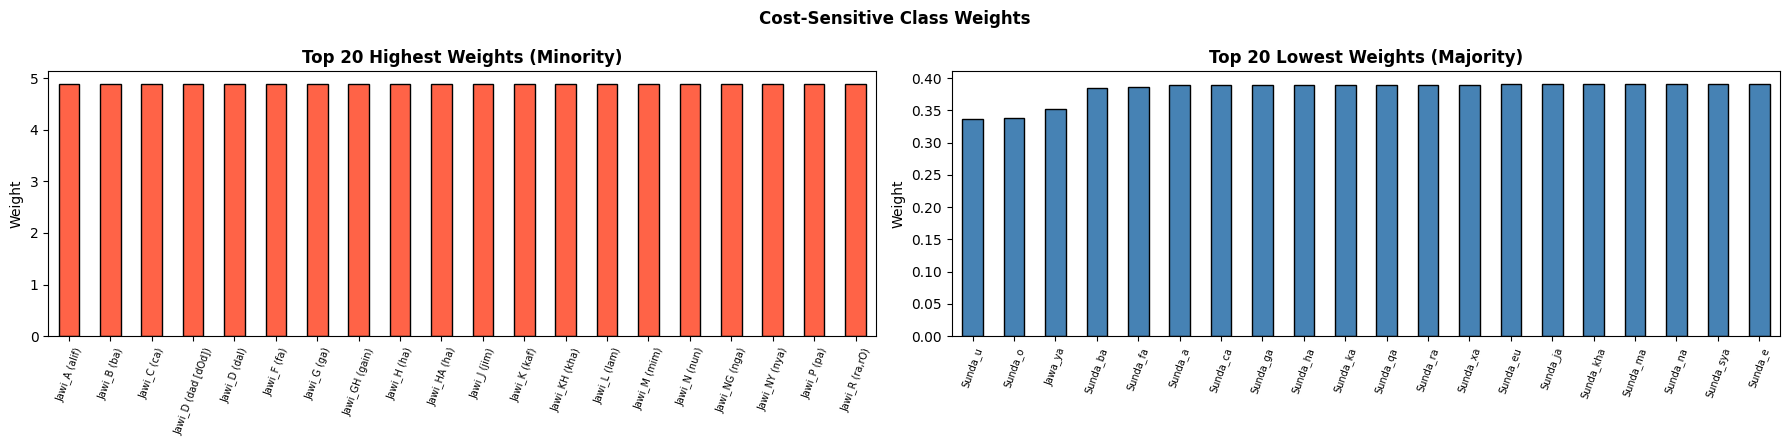

In [57]:
y_ref      = FEATURES[BACKBONES[0]]['train'][1]
unique_cls = np.unique(y_ref)
cw_arr     = compute_class_weight('balanced', classes=unique_cls, y=y_ref)
cw_dict    = dict(zip(unique_cls.tolist(), cw_arr.tolist()))

print(f'Classes weighted : {len(cw_arr)}')
print(f'Min / mean / max : {cw_arr.min():.3f}  {cw_arr.mean():.3f}  {cw_arr.max():.3f}')

ws = pd.Series(cw_arr, index=[CLASS_NAMES[i] for i in unique_cls])
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
ws.nlargest(20).plot(kind='bar',  ax=axes[0], color='tomato',    edgecolor='black')
ws.nsmallest(20).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[0].set_title('Top 20 Highest Weights (Minority)', fontweight='bold')
axes[1].set_title('Top 20 Lowest Weights (Majority)',  fontweight='bold')
for ax in axes:
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=70, labelsize=7)
plt.suptitle('Cost-Sensitive Class Weights', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_weights.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 6. Hyperparameter Tuning (Optuna TPE)

Simple search: 4–5 key parameters per model, 10 trials each, validated on a 10% stratified subsample with early stopping. Same subsample is shared across the three models for fair comparison.

In [58]:
def get_tune_splits(X, y, sw=None):
    _, sub_idx = train_test_split(
        np.arange(len(y)), test_size=TUNE_SUBSAMPLE,
        stratify=y, random_state=RANDOM_STATE,
    )
    Xs, ys = X[sub_idx], y[sub_idx]
    sws    = sw[sub_idx] if sw is not None else None
    tr, va = next(StratifiedShuffleSplit(1, test_size=0.15, random_state=RANDOM_STATE).split(Xs, ys))
    return Xs[tr], ys[tr], Xs[va], ys[va], (sws[tr] if sws is not None else None)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def xgb_objective(trial, X_tr, y_tr, X_va, y_va, sw_tr):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 250, step=50),
        max_depth        = trial.suggest_int('max_depth', 4, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        subsample        = trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.7, 1.0),
        eval_metric      = 'mlogloss',
        tree_method      = 'hist',
        device           = 'cuda',
        early_stopping_rounds = 15,
        random_state     = RANDOM_STATE,
        verbosity        = 0,
    )
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=[(X_va, y_va)], verbose=False)
    return macro_f1(y_va, model.predict(X_va))

def lgbm_objective(trial, X_tr, y_tr, X_va, y_va):
    params = dict(
        n_estimators  = trial.suggest_int('n_estimators', 100, 250, step=50),
        num_leaves    = trial.suggest_int('num_leaves', 31, 127),
        learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        reg_lambda    = trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        objective     = 'multiclass',
        metric        = 'multi_logloss',
        class_weight  = cw_dict,
        random_state  = RANDOM_STATE,
        # --- GPU SETTINGS ---
        device        = 'gpu',
        gpu_platform_id = 0,
        gpu_device_id   = 0,
        # --------------------
        verbose       = -1,
    )
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr, eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(15, verbose=False), lgb.log_evaluation(-1)],
    )
    return macro_f1(y_va, model.predict(X_va))

def cat_objective(trial, X_tr, y_tr, X_va, y_va):
    params = dict(
        iterations    = trial.suggest_int('iterations', 100, 250, step=50),
        depth         = trial.suggest_int('depth', 4, 8),
        learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
        l2_leaf_reg   = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        loss_function = 'MultiClass',
        eval_metric   = 'MultiClass',
        class_weights = list(cw_arr),
        random_seed   = RANDOM_STATE,
        # --- GPU SETTINGS ---
        task_type     = 'GPU',
        devices       = '0',
        # --------------------
        verbose       = False,
        allow_writing_files = False,
    )
    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=15)
    return macro_f1(y_va, model.predict(X_va).flatten())

n_tune = int(len(y_train) * TUNE_SUBSAMPLE)
print(f'Tuning on ~{n_tune:,} samples x {PCA_COMPONENTS}-d | {OPTUNA_TRIALS} trials/model')

Tuning on ~11,142 samples x 256-d | 10 trials/model


In [59]:
BEST_PARAMS = {}

for bb in BACKBONES:
    X_full, y_full = FEATURES[bb]['train']
    sw_full        = np.array([cw_dict[c] for c in y_full])
    X_tr_t, y_tr_t, X_va_t, y_va_t, sw_tr_t = get_tune_splits(X_full, y_full, sw_full)

    print(f'\n{"="*55}')
    print(f'  {bb}  |  tune: {len(y_tr_t):,} train  {len(y_va_t):,} val')
    print(f'{"="*55}')

    objectives = [
        ('xgb',  lambda t: xgb_objective(t,  X_tr_t, y_tr_t, X_va_t, y_va_t, sw_tr_t)),
        ('lgbm', lambda t: lgbm_objective(t, X_tr_t, y_tr_t, X_va_t, y_va_t)),
        ('cat',  lambda t: cat_objective(t,  X_tr_t, y_tr_t, X_va_t, y_va_t)),
    ]
    for name, fn in objectives:
        print(f'  Tuning {name.upper()} ...')
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        study.optimize(fn, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
        BEST_PARAMS[(bb, name)] = study.best_params
        print(f'    best val macro-F1: {study.best_value:.4f}')

joblib.dump(BEST_PARAMS, OUTPUT_DIR / 'best_params.pkl')
print('\nTuning complete.')


  mobilenet_v2  |  tune: 9,471 train  1,672 val
  Tuning XGB ...
    best val macro-F1: 0.7066
  Tuning LGBM ...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


    best val macro-F1: 0.6604
  Tuning CAT ...
    best val macro-F1: 0.6738

  efficientnet_b0  |  tune: 9,471 train  1,672 val
  Tuning XGB ...
    best val macro-F1: 0.7065
  Tuning LGBM ...
    best val macro-F1: 0.6815
  Tuning CAT ...
    best val macro-F1: 0.6758

Tuning complete.


In [60]:
for (bb, mk), params in BEST_PARAMS.items():
    print(f'\n[{bb}] [{mk.upper()}]')
    for k, v in params.items():
        print(f'  {k:<22} = {v}')


[mobilenet_v2] [XGB]
  n_estimators           = 200
  max_depth              = 4
  learning_rate          = 0.07496501097315299
  subsample              = 0.8099085529881075
  colsample_bytree       = 0.8368209952651108

[mobilenet_v2] [LGBM]
  n_estimators           = 200
  num_leaves             = 99
  learning_rate          = 0.05144736127521129
  reg_lambda             = 0.8123245085588685

[mobilenet_v2] [CAT]
  iterations             = 200
  depth                  = 4
  learning_rate          = 0.11607760868035455
  l2_leaf_reg            = 2.5347171131856236

[efficientnet_b0] [XGB]
  n_estimators           = 250
  max_depth              = 4
  learning_rate          = 0.10199291067622918
  subsample              = 0.8777243706586128
  colsample_bytree       = 0.7139351238159993

[efficientnet_b0] [LGBM]
  n_estimators           = 200
  num_leaves             = 99
  learning_rate          = 0.05144736127521129
  reg_lambda             = 0.8123245085588685

[efficientnet_b0] [CAT

---
## 7. Final Model Training

Refit on the full training set with `n_estimators=400` (scaled up from tuning) using cost-sensitive weights.

In [61]:
MODEL_DISPLAY = {'xgb': 'XGBoost', 'lgbm': 'LightGBM', 'cat': 'CatBoost'}
TRAINED       = {}

for bb in BACKBONES:
    X_tr, y_tr = FEATURES[bb]['train']
    sw = np.array([cw_dict[c] for c in y_tr])
    print(f'\nTraining final models on [{bb}]  ({len(X_tr):,} x {X_tr.shape[1]})')

    # XGBoost
    xp = {**BEST_PARAMS[(bb, 'xgb')]}
    xp.update(dict(
        n_estimators = FINAL_ESTIMATORS,
        eval_metric  = 'mlogloss',
        tree_method  = 'hist',
        device       = 'cuda',
        random_state = RANDOM_STATE,
        n_jobs       = -1,
        verbosity    = 0,
    ))
    t0 = time.time()
    xgb_model = xgb.XGBClassifier(**xp)
    xgb_model.fit(X_tr, y_tr, sample_weight=sw, verbose=False)
    print(f'  XGBoost  {time.time()-t0:.0f}s')
    joblib.dump(xgb_model, OUTPUT_DIR / f'{bb}_xgb.pkl')
    TRAINED[(bb, 'xgb')] = xgb_model

    # LightGBM (CPU is fine here; lightgbm GPU build is rarely available)
    lp = {**BEST_PARAMS[(bb, 'lgbm')]}
    lp.update(dict(
        n_estimators = FINAL_ESTIMATORS,
        objective    = 'multiclass',
        metric       = 'multi_logloss',
        class_weight = cw_dict,
        random_state = RANDOM_STATE,
        # --- GPU SETTINGS ---
        device       = 'gpu',
        gpu_platform_id = 0,
        gpu_device_id   = 0,
        # --------------------
        verbose      = -1,
    ))
    t0 = time.time()
    lgbm_model = lgb.LGBMClassifier(**lp)
    lgbm_model.fit(X_tr, y_tr)
    print(f'  LightGBM {time.time()-t0:.0f}s')
    joblib.dump(lgbm_model, OUTPUT_DIR / f'{bb}_lgbm.pkl')
    TRAINED[(bb, 'lgbm')] = lgbm_model

    # CatBoost
    cp = BEST_PARAMS[(bb, 'cat')]
    cat_kwargs = dict(
        iterations    = FINAL_ESTIMATORS,
        depth         = cp.get('depth', 6),
        learning_rate = cp.get('learning_rate', 0.1),
        l2_leaf_reg   = cp.get('l2_leaf_reg', 3.0),
        loss_function = 'MultiClass',
        eval_metric   = 'MultiClass',
        class_weights = list(cw_arr),
        random_seed   = RANDOM_STATE,
        verbose       = False,
        allow_writing_files = False,
    )
    cat_kwargs.update(task_type='GPU', devices='0')
    t0 = time.time()
    cat_model = CatBoostClassifier(**cat_kwargs)
    cat_model.fit(X_tr, y_tr)
    print(f'  CatBoost {time.time()-t0:.0f}s')
    cat_model.save_model(str(OUTPUT_DIR / f'{bb}_catboost.cbm'))
    TRAINED[(bb, 'cat')] = cat_model

print('\nAll 6 models trained and saved.')


Training final models on [mobilenet_v2]  (44,570 x 256)
  XGBoost  257s
  LightGBM 1482s
  CatBoost 127s

Training final models on [efficientnet_b0]  (44,570 x 256)
  XGBoost  226s
  LightGBM 1455s
  CatBoost 126s

All 6 models trained and saved.


---
## 8. Evaluation

In [62]:
RESULTS, PREDICTIONS = [], {}

for bb in BACKBONES:
    X_te, y_te = FEATURES[bb]['test']
    for mk in ['xgb', 'lgbm', 'cat']:
        model  = TRAINED[(bb, mk)]
        y_pred = np.array(model.predict(X_te)).flatten().astype(int)
        PREDICTIONS[(bb, mk)] = y_pred

        acc = accuracy_score(y_te, y_pred)
        mp  = precision_score(y_te, y_pred, average='macro', zero_division=0)
        mr  = recall_score(y_te, y_pred, average='macro', zero_division=0)
        mf1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

        RESULTS.append({
            'Backbone': bb, 'Model': MODEL_DISPLAY[mk],
            'Accuracy': round(acc, 4), 'Macro Precision': round(mp, 4),
            'Macro Recall': round(mr, 4), 'Macro F1': round(mf1, 4),
        })
        print(f'[{bb}] {MODEL_DISPLAY[mk]:<10}  '
              f'F1={mf1:.4f}  Acc={acc:.4f}  P={mp:.4f}  R={mr:.4f}')

[mobilenet_v2] XGBoost     F1=0.8529  Acc=0.8408  P=0.8602  R=0.8513
[mobilenet_v2] LightGBM    F1=0.8214  Acc=0.8019  P=0.8229  R=0.8247
[mobilenet_v2] CatBoost    F1=0.8519  Acc=0.8190  P=0.8478  R=0.8607
[efficientnet_b0] XGBoost     F1=0.8494  Acc=0.8440  P=0.8577  R=0.8466
[efficientnet_b0] LightGBM    F1=0.8221  Acc=0.8054  P=0.8289  R=0.8224
[efficientnet_b0] CatBoost    F1=0.8469  Acc=0.8141  P=0.8471  R=0.8515


In [63]:
results_df = pd.DataFrame(RESULTS).sort_values('Macro F1', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print('── Model Comparison (sorted by Macro F1) ──')
display(results_df)

── Model Comparison (sorted by Macro F1) ──


,Backbone,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,mobilenet_v2,XGBoost,0.8408,0.8602,0.8513,0.8529
2,mobilenet_v2,CatBoost,0.8190,0.8478,0.8607,0.8519
3,efficientnet_b0,XGBoost,0.8440,0.8577,0.8466,0.8494
4,efficientnet_b0,CatBoost,0.8141,0.8471,0.8515,0.8469
5,efficientnet_b0,LightGBM,0.8054,0.8289,0.8224,0.8221
6,mobilenet_v2,LightGBM,0.8019,0.8229,0.8247,0.8214


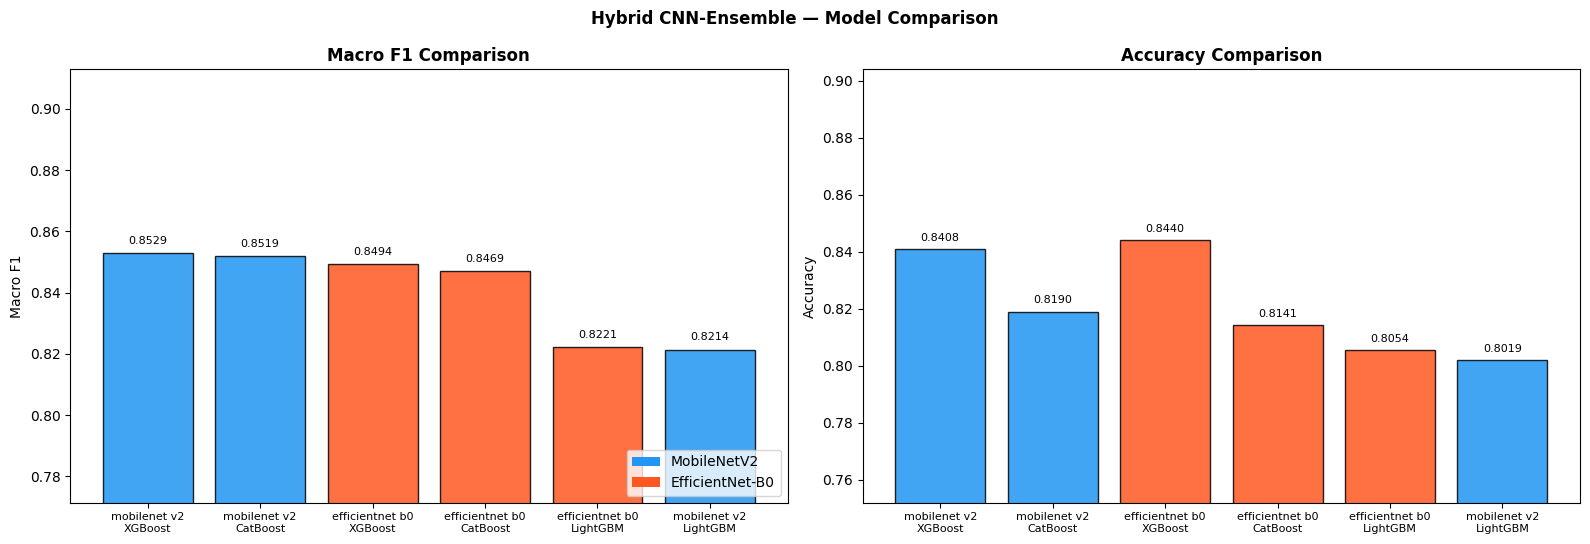

In [64]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
labels = [f"{r['Backbone'].replace('_',' ')}\n{r['Model']}" for _, r in results_df.iterrows()]
colors = ['#2196F3' if 'mobilenet' in r['Backbone'] else '#FF5722' for _, r in results_df.iterrows()]

for ax, metric in zip(axes, ['Macro F1', 'Accuracy']):
    vals = results_df[metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.06))
    ax.tick_params(axis='x', labelsize=8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{v:.4f}', ha='center', fontsize=8)

axes[0].legend(handles=[Patch(facecolor='#2196F3', label='MobileNetV2'),
                         Patch(facecolor='#FF5722', label='EfficientNet-B0')],
                loc='lower right')
plt.suptitle('Hybrid CNN-Ensemble — Model Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [65]:
best_row = results_df.iloc[0]
best_bb  = best_row['Backbone']
best_mk  = {v: k for k, v in MODEL_DISPLAY.items()}[best_row['Model']]
_, y_te_best = FEATURES[best_bb]['test']
y_pred_best  = PREDICTIONS[(best_bb, best_mk)]

report = classification_report(
    y_te_best, y_pred_best, target_names=CLASS_NAMES, digits=4, zero_division=0,
)
with open(OUTPUT_DIR / 'best_model_report.txt', 'w') as f:
    f.write(f"{best_bb} + {best_row['Model']}  Macro-F1={best_row['Macro F1']}\n\n{report}")

print(f"Best: [{best_bb}] + [{best_row['Model']}]  Macro-F1={best_row['Macro F1']}\n")
print(report)

Best: [mobilenet_v2] + [XGBoost]  Macro-F1=0.8529

                        precision    recall  f1-score   support

               Bali_ba     0.5902    0.7200    0.6486        50
               Bali_ca     0.7143    0.7000    0.7071        50
               Bali_da     0.6491    0.7551    0.6981        49
               Bali_ga     0.8649    0.6531    0.7442        49
               Bali_ha     0.6727    0.7400    0.7048        50
               Bali_ja     0.7111    0.6400    0.6737        50
               Bali_ka     0.7500    0.8400    0.7925        50
               Bali_la     0.6481    0.7000    0.6731        50
               Bali_ma     0.6596    0.6200    0.6392        50
               Bali_na     0.8936    0.8400    0.8660        50
              Bali_nga     0.6000    0.6600    0.6286        50
              Bali_nya     0.8222    0.7400    0.7789        50
               Bali_pa     0.7021    0.6600    0.6804        50
               Bali_ra     0.7544    0.8600    0.803

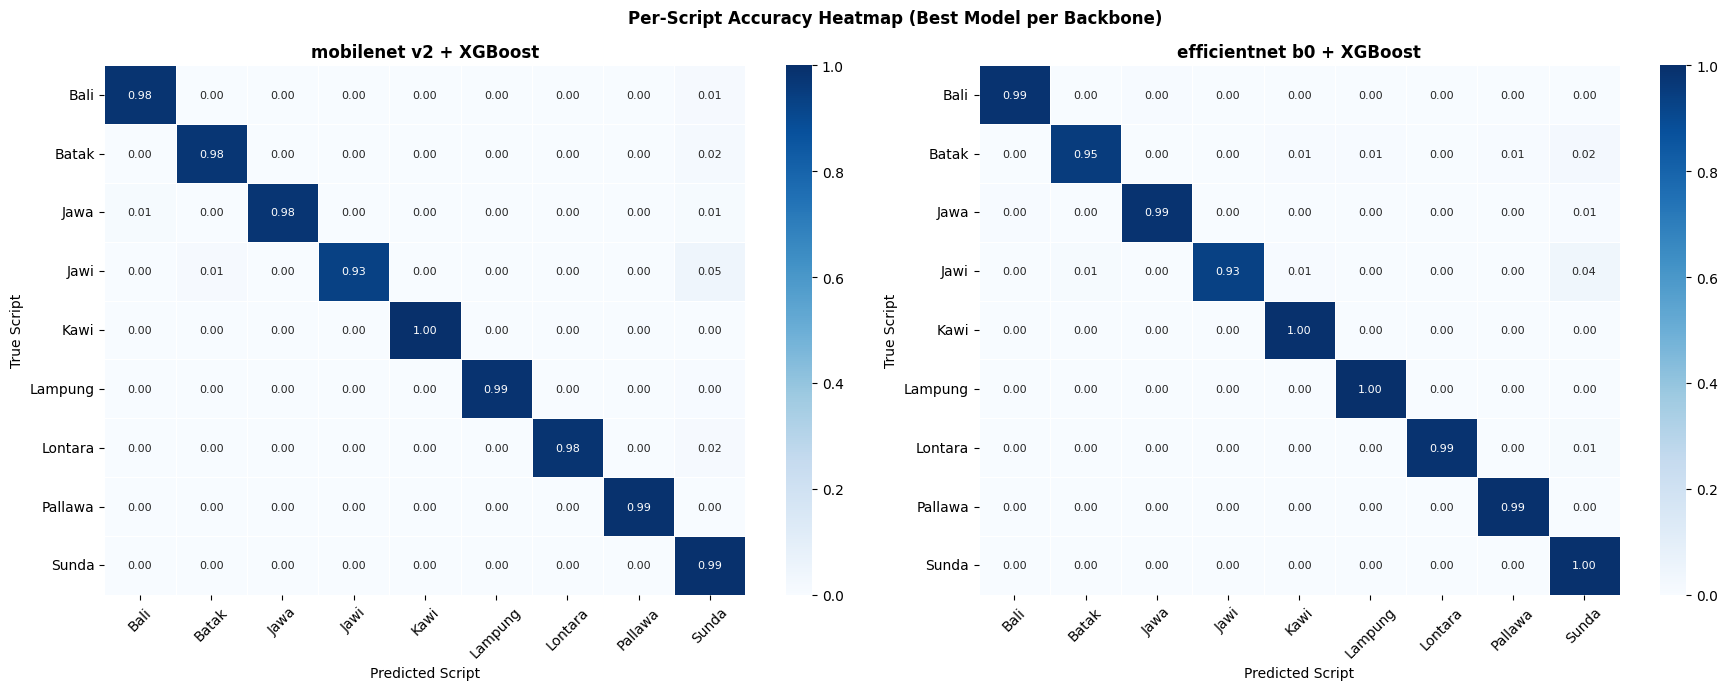

In [66]:
# Per-script accuracy heatmap (9 x 9) for the top model of each backbone
label_to_script = {i: CLASS_NAMES[i].split('_')[0] for i in range(N_CLASSES)}
scripts_ord     = sorted(df['script'].unique())
script_idx      = {s: i for i, s in enumerate(scripts_ord)}

def script_confusion(y_true, y_pred):
    n  = len(scripts_ord)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[script_idx[label_to_script[int(t)]], script_idx[label_to_script[int(p)]]] += 1
    rs = cm.sum(axis=1, keepdims=True)
    return cm / np.where(rs == 0, 1, rs)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, bb in zip(axes, BACKBONES):
    _, y_te_b = FEATURES[bb]['test']
    top_model = results_df[results_df['Backbone'] == bb].iloc[0]['Model']
    top_key   = {v: k for k, v in MODEL_DISPLAY.items()}[top_model]
    sm = script_confusion(y_te_b, PREDICTIONS[(bb, top_key)])
    sns.heatmap(sm, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5,
                xticklabels=scripts_ord, yticklabels=scripts_ord,
                vmin=0, vmax=1, ax=ax, annot_kws={'size': 8})
    ax.set_title(f"{bb.replace('_',' ')} + {top_model}", fontweight='bold')
    ax.set_xlabel('Predicted Script'); ax.set_ylabel('True Script')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)

plt.suptitle('Per-Script Accuracy Heatmap (Best Model per Backbone)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_script_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

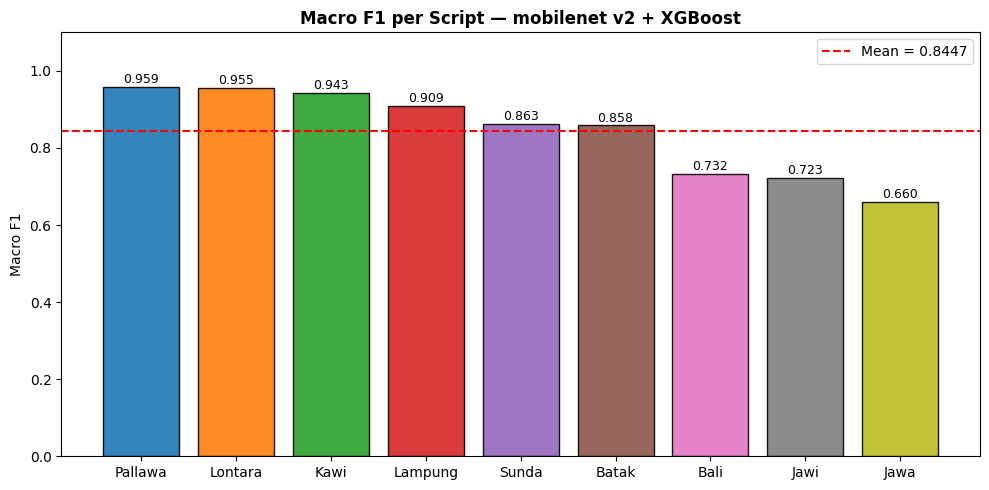

In [67]:
# Macro F1 per script (best overall model)
rep_dict = classification_report(
    y_te_best, y_pred_best, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0,
)
script_f1 = {}
for lbl, vals in rep_dict.items():
    if '_' in lbl and isinstance(vals, dict):
        script_f1.setdefault(lbl.split('_')[0], []).append(vals['f1-score'])
script_f1_mean = pd.Series({s: np.mean(v) for s, v in script_f1.items()}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(script_f1_mean.index, script_f1_mean.values, color=PALETTE, edgecolor='black', alpha=0.9)
ax.axhline(script_f1_mean.mean(), color='red', linestyle='--',
           label=f'Mean = {script_f1_mean.mean():.4f}')
ax.set_title(f"Macro F1 per Script — {best_bb.replace('_',' ')} + {best_row['Model']}",
             fontweight='bold')
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.1); ax.legend()
for b, v in zip(bars, script_f1_mean.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'macro_f1_per_script.png', dpi=130, bbox_inches='tight')
plt.show()

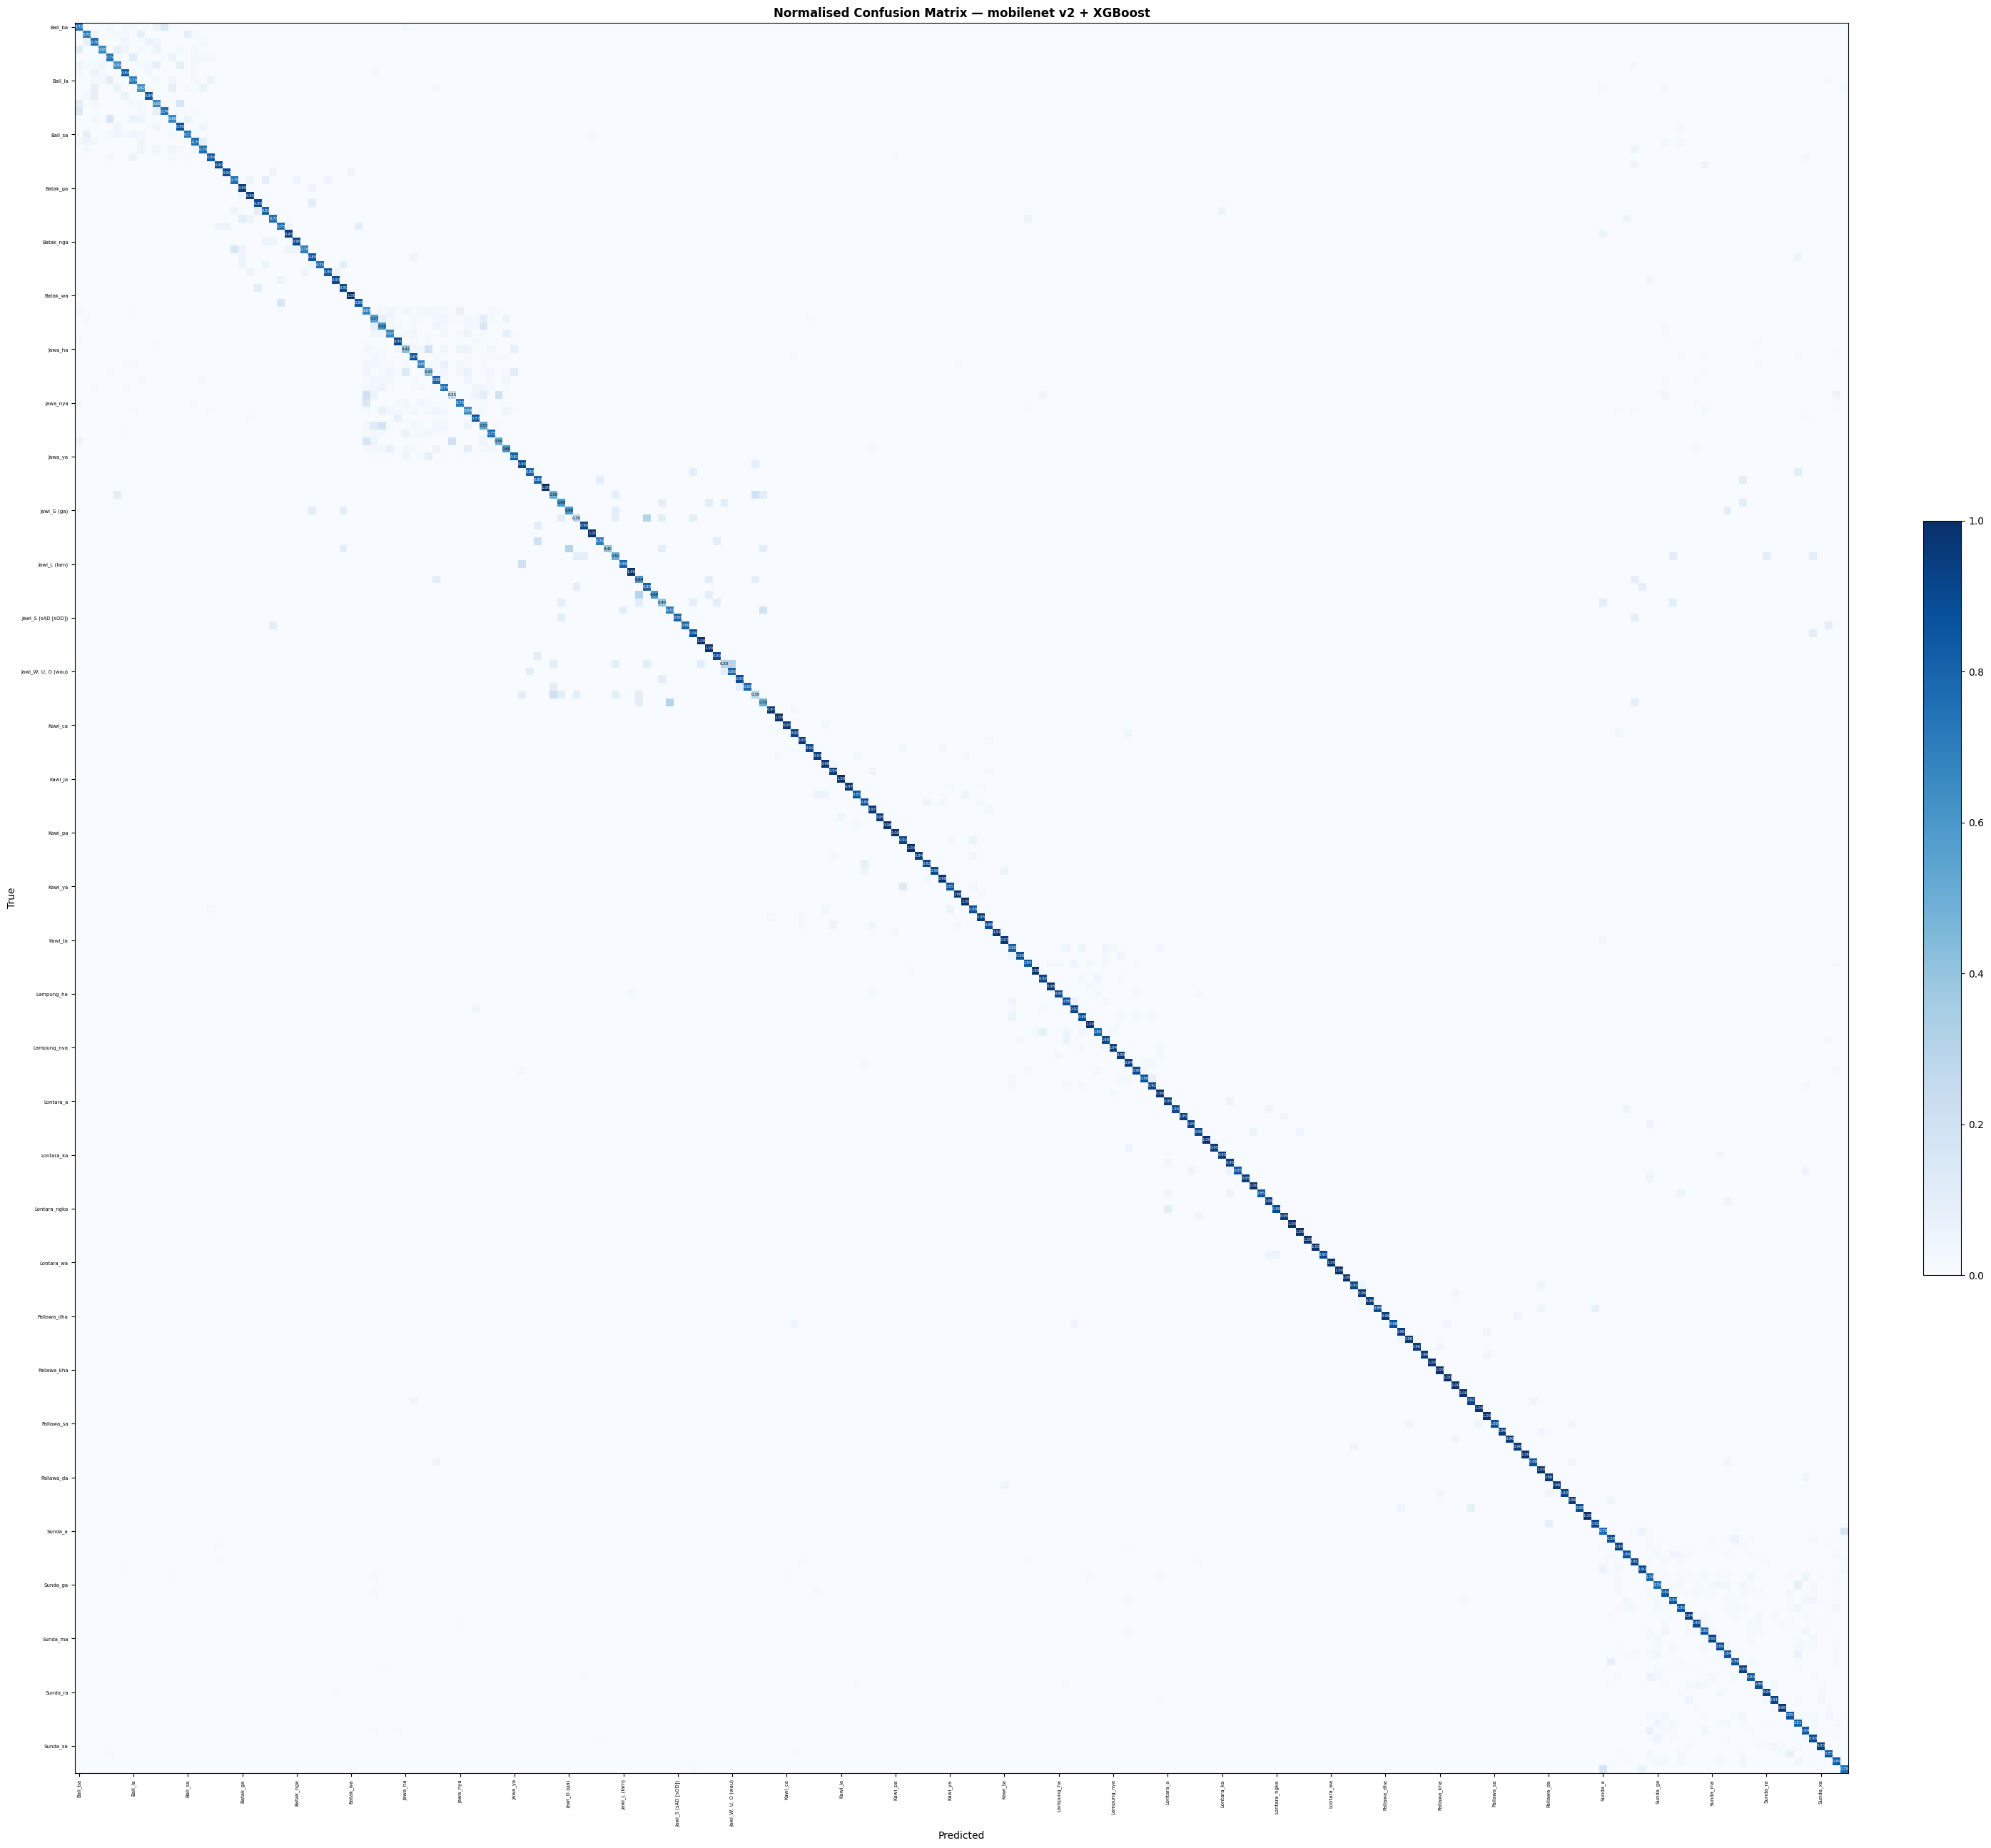

In [68]:
# Full 228x228 confusion matrix for the best model
cm_full = confusion_matrix(y_te_best, y_pred_best)
cm_norm = cm_full.astype(float) / np.where(cm_full.sum(1, keepdims=True) == 0, 1,
                                            cm_full.sum(1, keepdims=True))

fig, ax = plt.subplots(figsize=(28, 26))
im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)

for i in range(N_CLASSES):
    ax.text(i, i, f'{cm_norm[i, i]:.2f}', ha='center', va='center',
            fontsize=4, color='white' if cm_norm[i, i] > 0.6 else 'black')

step  = max(1, N_CLASSES // 30)
ticks = list(range(0, N_CLASSES, step))
ax.set_xticks(ticks); ax.set_xticklabels([CLASS_NAMES[i] for i in ticks], rotation=90, fontsize=5)
ax.set_yticks(ticks); ax.set_yticklabels([CLASS_NAMES[i] for i in ticks], fontsize=5)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f"Normalised Confusion Matrix — {best_bb.replace('_',' ')} + {best_row['Model']}",
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_best.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 9. Inference Demo

In [69]:
@torch.no_grad()
def predict_image(image_path, extractor, pca, model, label_enc, top_k=5):
    img = Image.open(image_path)
    if img.mode == 'RGBA':
        bg = Image.new('RGB', img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    elif img.mode == 'P':
        img = img.convert('RGBA').convert('RGB')
    else:
        img = img.convert('RGB')

    binary = binarize_pil(img.convert('L'))
    tensor = BASE_TRANSFORM(to_rgb_3ch(binary)).unsqueeze(0).to(DEVICE)

    if DEVICE.type == 'cuda':
        with torch.amp.autocast('cuda', dtype=torch.float16):
            feat = extractor(tensor).float().cpu().numpy()
    else:
        feat = extractor(tensor).cpu().numpy()
    feat_red = pca.transform(feat).astype(np.float32)

    pred_enc   = int(np.array(model.predict(feat_red)).flatten()[0])
    pred_label = label_enc.inverse_transform([pred_enc])[0]

    top_k_out = None
    if hasattr(model, 'predict_proba'):
        proba   = model.predict_proba(feat_red)[0]
        top_idx = np.argsort(proba)[::-1][:top_k]
        top_k_out = [(label_enc.inverse_transform([i])[0], round(float(proba[i]), 4))
                     for i in top_idx]
    return {
        'predicted_label': pred_label,
        'script'         : pred_label.split('_')[0],
        'character'      : '_'.join(pred_label.split('_')[1:]),
        'top_k'          : top_k_out,
    }

print('Inference function ready.')

Inference function ready.


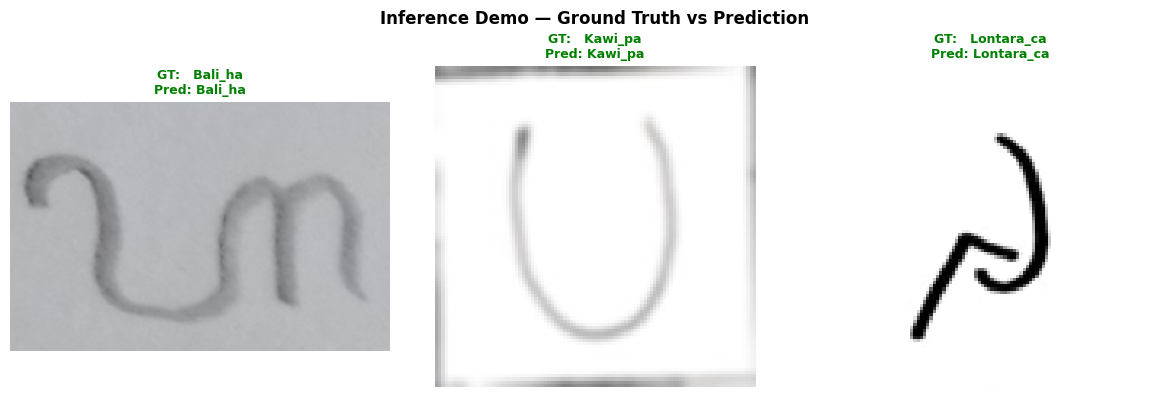


Top-5 predictions for 'Bali_ha':
  1. Bali_ha                        0.9959
  2. Bali_ta                        0.0019
  3. Bali_wa                        0.0003
  4. Bali_sa                        0.0003
  5. Bali_ya                        0.0001


In [70]:
inf_extractor = build_extractor(best_bb)
inf_pca       = PCA_MODELS[best_bb]
inf_model     = TRAINED[(best_bb, best_mk)]

demo_scripts = ['Bali', 'Kawi', 'Lontara']
demo_rows = [df[df['script'] == s].sample(1, random_state=RANDOM_STATE + 7).iloc[0]
             for s in demo_scripts]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, row in zip(axes, demo_rows):
    result = predict_image(row['filepath'], inf_extractor, inf_pca, inf_model, le)
    ax.imshow(Image.open(row['filepath']).convert('RGB'))
    ax.axis('off')
    color = 'green' if row['label'] == result['predicted_label'] else 'red'
    ax.set_title(f"GT:   {row['label']}\nPred: {result['predicted_label']}",
                 color=color, fontsize=9, fontweight='bold')
plt.suptitle('Inference Demo — Ground Truth vs Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'inference_demo.png', dpi=130, bbox_inches='tight')
plt.show()

r = predict_image(demo_rows[0]['filepath'], inf_extractor, inf_pca, inf_model, le)
print(f"\nTop-5 predictions for '{demo_rows[0]['label']}':")
if r['top_k']:
    for rank, (lbl, prob) in enumerate(r['top_k'], 1):
        print(f'  {rank}. {lbl:<30} {prob:.4f}')

---
## 10. Final Summary

In [71]:
with open(OUTPUT_DIR / 'feature_extractor_name.txt', 'w') as f:
    f.write(best_bb)

print('=' * 65)
print('  HCR NUSANTARA — EXPERIMENT SUMMARY')
print('=' * 65)
print(f'  Dataset       : 9 Indonesian local scripts')
print(f'  Total images  : {len(df):,}')
print(f'  Total classes : {N_CLASSES}')
print(f'  Train / Test  : {len(X_train):,} / {len(X_test):,}  (stratified 80/20)')
print(f'  Backbones     : MobileNetV2, EfficientNet-B0 (frozen ImageNet)')
print(f'  Feature dim   : 1280 -> {PCA_COMPONENTS} (PCA)')
print(f'  Class balance : compute_class_weight("balanced")')
print(f'  HP tuning     : Optuna TPE, {OPTUNA_TRIALS} trials/model on {int(TUNE_SUBSAMPLE*100)}% subsample')
print(f'  Device        : {DEVICE}  (GPU tree training: {USE_GPU_TREES})')
print()
print('  ── Results (sorted by Macro F1) ──')
print(results_df.to_string(index=True))
print()
print(f"  Best model    : {best_bb} + {best_row['Model']}")
print(f"  Macro F1      : {best_row['Macro F1']}")
print(f"  Accuracy      : {best_row['Accuracy']}")
print()
print('  Saved artifacts:')
for fp in sorted(OUTPUT_DIR.iterdir()):
    print(f'    {fp.name}')
print('=' * 65)

  HCR NUSANTARA — EXPERIMENT SUMMARY
  Dataset       : 9 Indonesian local scripts
  Total images  : 55,713
  Total classes : 228
  Train / Test  : 44,570 / 11,143  (stratified 80/20)
  Backbones     : MobileNetV2, EfficientNet-B0 (frozen ImageNet)
  Feature dim   : 1280 -> 256 (PCA)
  Class balance : compute_class_weight("balanced")
  HP tuning     : Optuna TPE, 10 trials/model on 25% subsample
  Device        : cuda  (GPU tree training: True)

  ── Results (sorted by Macro F1) ──
          Backbone     Model  Accuracy  Macro Precision  Macro Recall  Macro F1
1     mobilenet_v2   XGBoost    0.8408           0.8602        0.8513    0.8529
2     mobilenet_v2  CatBoost    0.8190           0.8478        0.8607    0.8519
3  efficientnet_b0   XGBoost    0.8440           0.8577        0.8466    0.8494
4  efficientnet_b0  CatBoost    0.8141           0.8471        0.8515    0.8469
5  efficientnet_b0  LightGBM    0.8054           0.8289        0.8224    0.8221
6     mobilenet_v2  LightGBM    0.